In [ ]:
import xarray as xr
import numpy as np
import cftime
import cmocean as cm
import matplotlib.pyplot as plt
import regionmask
from xmip.regionmask import merged_mask
import cartopy.crs as ccrs
import os
import pandas as pd
from pandas import Timestamp
from xarrayutils.plotting import linear_piecewise_scale


In [ ]:
# Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-03_ConvNextUNetTrain3DEval3DHist1Epoch70Years100-1996_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr'
# Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-06_ConvNextUNetTrain3DEval3DClimateChangeForcingHist1Epoch70Years100-1996_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr'
# Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-07_ConvNextUNetTrain3Dv021Eval3DhfdsanomsEpochs70Epoch55Years100-1996_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr'
# Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-07_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms3xCCEpochs70Epoch55Years100-1996_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #3x
# Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-07_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNoccEpochs70Epoch55Years100_10repeat-1996_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #10 year
# Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-07_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms3xCCEpochs70Epoch55Years100_10repeat-1996_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # 10 year climate
# Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-08_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms15xCCEpochs70Epoch55Years100_10repeat-1996_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # 10 year climate
Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-08_ConvNextUNetTrain3Dv021Eval3Dhfdsanomsnojump3xccEpochs70Epoch55Years100_10repeat-1996_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # no jump

In [ ]:
dates = np.array([  3,   8,  13,  18,  23,  28,  33,  38,  43,  48,  53,  58,  63,
        68,  73,  78,  83,  88,  93,  98, 103, 108, 113, 118, 123, 128,
       133, 138, 143, 148, 153, 158, 163, 168, 173, 178, 183, 188, 193,
       198, 203, 208, 213, 218, 223, 228, 233, 238, 243, 248, 253, 258,
       263, 268, 273, 278, 283, 288, 293, 298, 303, 308, 313, 318, 323,
       328, 333, 338, 343, 348, 353, 358, 363])

def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})


    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})
    # ds_out = ds_out.assign_coords({'time':ds_truth.time[:3850].data})
    return ds_out

import os
import pandas as pd

levels = 19
emulation_stability=True
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/pscratch/sd/s/suryad/data", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data 
if smooth:
    window = 10
    with ProgressBar():
        ds_input['uo'] = ds_input.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
        ds_input['vo'] = ds_input.vo.rolling(time=window, min_periods=1, center=False).mean().compute()


# our groundtruth is always just a time slice of the training (training is a bad name

if emulation_stability:
    repeats = 100
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = np.array([np.datetime64('1996') + np.timedelta64(day-1,'D') for day in dates])
    for i in range(1,repeats):
        new_time = np.hstack((new_time,np.array([np.datetime64(str(1996+i)) + np.timedelta64(day-1,'D') for day in dates])))
    # new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time[:7300]
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 7003))
else:
    ds_groundtruth = ds_input.isel(time=slice(4143, 4743)).isel(lev=slice(None, levels))


ls = ['uo', 'vo', 'thetao', 'so', 'zos'] #['uo', 'vo', 'thetao', 'so', 'zos'], ['thetao', 'so', 'zos']

# Pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-08-20_ConvNextUNetTrain3Dv021Eval3DEpochs70Epoch70_Train_global_3D_Test_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_4000_rand_seed_1.zarr'
output_folder = Pred_path.split("/")[-2].split("_Train")[0]
output_path = os.path.join("./temp", output_folder)

if os.path.isdir(output_path):
    print("Using Output Folder : ", output_path)
else:
    print("Using Output Folder : ../outputs")
    output_path = "../outputs"

ds_prediction_raw = xr.open_zarr(Pred_path)

# if emulation_stability:
#     ds_groundtruth = ds_groundtruth.isel(time=slice(0, ds_prediction_raw.time.size))

ds_prediction = post_processor(
    ds_prediction_raw, ds_groundtruth, ls
)

# Run the test to make sure the output is formatted correctly


In [36]:
ds_prediction = ds_prediction.transpose('time','lev',...)

In [37]:
ds_prediction['y']  = ds_prediction.y.assign_attrs(long_name='latitude')
ds_prediction['x']  = ds_prediction.x.assign_attrs(long_name='longitude')
ds_prediction['thetao'] = ds_prediction['thetao'].assign_attrs(long_name = 'Temperature', units = 'K')

/tmp/ipykernel_1486857/2611374610.py:3: UserWarning: `natural_earth_v4_1_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50
/global/homes/a/asubel/.conda/envs/NERSC_Kernel/lib/python3.12/site-packages/regionmask/core/mask.py:179: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


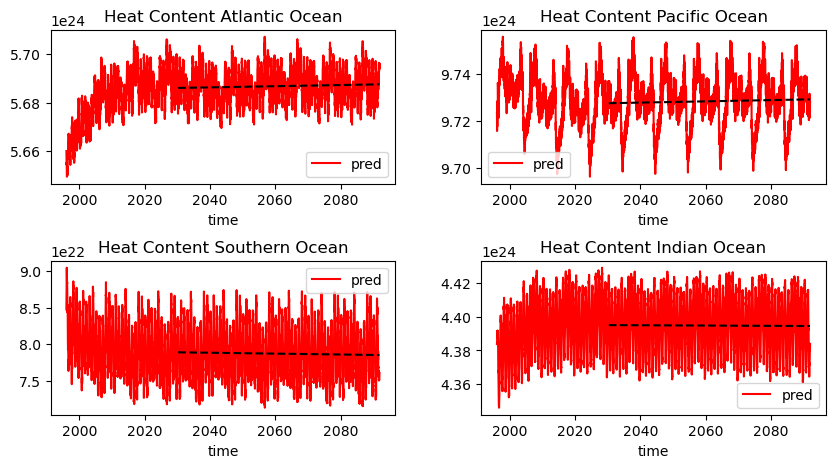

In [6]:
# Compute Basin Heat Content Time Series

basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

mask = merged_mask(basins,ds_prediction.drop_vars(['lat','lon']))

atlantic_mask = xr.where(np.logical_or(mask == 0,mask == 1),1.0,np.nan)
pacific_mask = xr.where(np.logical_or(mask == 2,mask == 3),1.0,np.nan)
southern_ocean_mask = xr.where(mask == 7,1.0,np.nan)
indian_ocean_mask = xr.where(mask == 5,1.0,np.nan)

masks = atlantic_mask.to_dataset(name='Atlantic')
masks['Pacific']  = pacific_mask
masks['Southern'] = southern_ocean_mask
masks['Indian'] = indian_ocean_mask

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
ax_flat = ax.flatten()

for i, var in enumerate(list(masks.keys())):
    OHC_pred = ((ds_prediction['thetao']*c_p*rho_0*masks[var])*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    

    OHC_pred.plot(ax = ax_flat[i], label = 'pred', c = 'r')
    ax_flat[i].legend()
    ax_flat[i].set_title("Heat Content " + var + " Ocean")
    coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[2500:].size), OHC_pred[2500:], 1)
    ax_flat[i].plot(OHC_pred[2500:].time.data, np.arange(OHC_pred[2500:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'k', ls = '--')

# fig.savefig('./figures/OHC_Short.png',dpi=250)

-0.024795059762331817
-0.13390667646347532


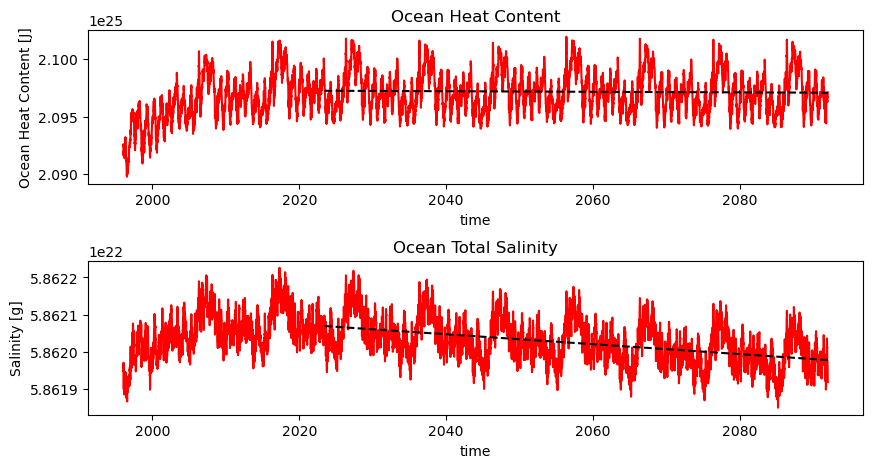

In [38]:
Days_to_Eq = 2000

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,1,figsize=(10,5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred = ((ds_prediction['thetao']*c_p*rho_0)*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
OHC_pred = OHC_pred.rename('Ocean Heat Content')
OHC_pred = OHC_pred.assign_attrs(units = 'J')

OHC_pred.plot(ax = ax[0], label = 'pred', c = 'r')
# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[Days_to_Eq:].size), OHC_pred[Days_to_Eq:], 1)
ax[0].plot(OHC_pred[Days_to_Eq:].time.data, np.arange(OHC_pred[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'k', ls = '--')

salinity = ((ds_prediction['so']*rho_0)*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
salinity = salinity.rename('Salinity')
salinity = salinity.assign_attrs(units = 'g')

salinity.plot(ax = ax[1], label = 'pred', c = 'r')
# ax[1].legend()
ax[1].set_title("Ocean Total Salinity")
coeffs_salinity_trend= np.polyfit(np.arange(salinity[Days_to_Eq:].size), salinity[Days_to_Eq:], 1)
ax[1].plot(salinity[Days_to_Eq:].time.data, np.arange(salinity[Days_to_Eq:].size)*coeffs_salinity_trend[0] + coeffs_salinity_trend[1],c = 'k', ls = '--')

print(coeffs_OHC_pred_trend[0]*73/1e21)

print(coeffs_salinity_trend[0]*73/1e17)

fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Time Series 10 year repeat warming.png')

-0.00021499616531413436
-0.021563192003534636


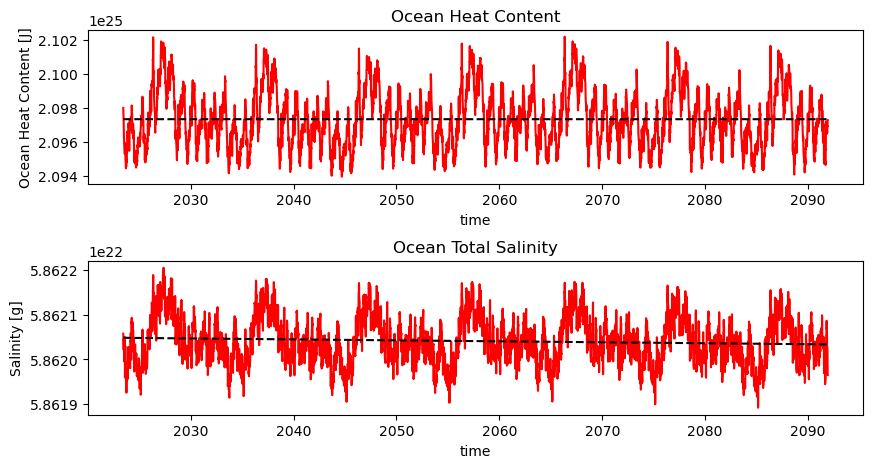

In [26]:
Days_to_Eq = 2000

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,1,figsize=(10,5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred = ((ds_prediction['thetao'][Days_to_Eq:]*c_p*rho_0)*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
OHC_pred = OHC_pred.rename('Ocean Heat Content')
OHC_pred = OHC_pred.assign_attrs(units = 'J')

OHC_pred.plot(ax = ax[0], label = 'pred', c = 'r')
# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[:].size), OHC_pred[:], 1)
ax[0].plot(OHC_pred[:].time.data, np.arange(OHC_pred[:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'k', ls = '--')

salinity = ((ds_prediction['so'][Days_to_Eq:]*rho_0)*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
salinity = salinity.rename('Salinity')
salinity = salinity.assign_attrs(units = 'g')

salinity.plot(ax = ax[1], label = 'pred', c = 'r')
# ax[1].legend()
ax[1].set_title("Ocean Total Salinity")
coeffs_salinity_trend= np.polyfit(np.arange(salinity[:].size), salinity[:], 1)
ax[1].plot(salinity[:].time.data, np.arange(salinity[:].size)*coeffs_salinity_trend[0] + coeffs_salinity_trend[1],c = 'k', ls = '--')

print(coeffs_OHC_pred_trend[0]*73/1e21)

print(coeffs_salinity_trend[0]*73/1e17)

fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Time Series 10 year repeat no spin up.png')

In [40]:
hfs_true = xr.open_zarr("/pscratch/sd/s/suryad/data/OM4_5daily_v0.2.1.zarr").drop_vars(['lon','lat'])['hfds']
hfs_true = hfs_true.sel(time = slice('1990-01-01','1999-12-31')).transpose('time',...)
hfs_true =  xr.concat([hfs_true] * repeats, dim="time")

In [42]:
seconds_per_step = 86400*5
Days_to_Eq = 1000

total_heat_flux = (hfs_true[Days_to_Eq:]*ds_prediction['areacello']).sum(['x','y'])
heat_added = np.trapz(total_heat_flux.values,dx = seconds_per_step)

heat_added_pred = OHC_pred[-1].values-OHC_pred[Days_to_Eq].values

print(heat_added)
print(heat_added_pred)

4.119275013037782e+23
2.451932950449978e+22


In [23]:
fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Time Series 10 year repeat no spin up.png')

Text(0.2, 0.95, 'OHC portion of trend: -0.04')

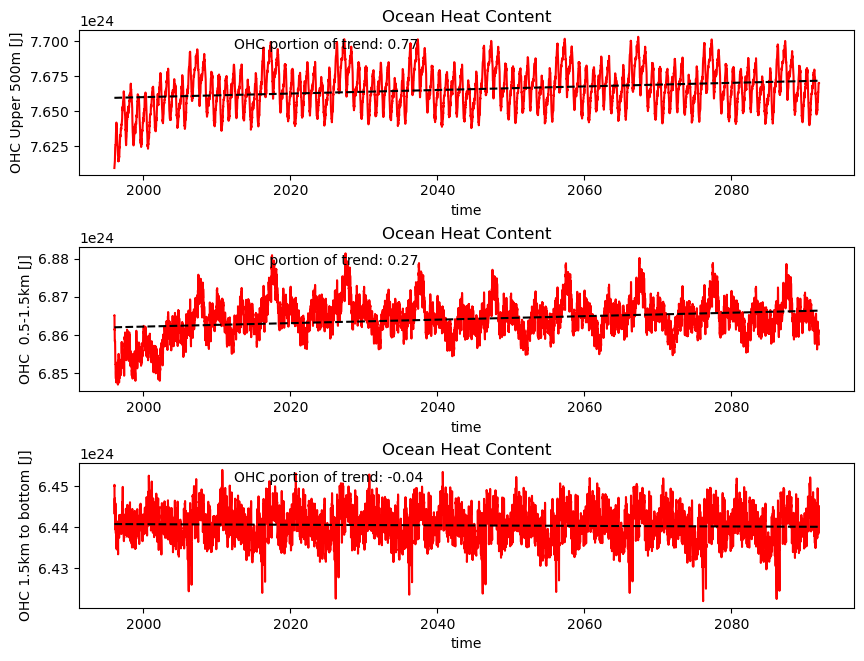

In [8]:
# Compute Basin Heat Content Time Series

Days_to_Eq = 0
c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(3,1,figsize=(10,7.5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred_upper = ((ds_prediction['thetao'].sel(lev = slice(0,500))*c_p*rho_0)*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
OHC_pred_upper = OHC_pred_upper.rename('OHC Upper 500m')
OHC_pred_upper = OHC_pred_upper.assign_attrs(units = 'J')

OHC_pred_upper.plot(ax = ax[0], label = 'pred', c = 'r')
# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_upper[Days_to_Eq:].size), OHC_pred_upper[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper[Days_to_Eq:].time.data, np.arange(OHC_pred_upper[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'k', ls = '--')
upper_trend = coeffs_OHC_pred_trend[0]*73
# ax[0].annotate(f'OHC trend: {upper_trend:.2f} j/year',xy = (.25,.75), xycoords='figure fraction',
#             horizontalalignment='left', verticalalignment='top')

OHC_pred_mid = ((ds_prediction['thetao'].sel(lev = slice(500,1500))*c_p*rho_0)*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
OHC_pred_mid = OHC_pred_mid.rename('OHC  0.5-1.5km')
OHC_pred_mid = OHC_pred_mid.assign_attrs(units = 'J')

OHC_pred_mid.plot(ax = ax[1], label = 'pred', c = 'r')
# ax[0].legend()
ax[1].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_mid[Days_to_Eq:].size), OHC_pred_mid[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid[Days_to_Eq:].time.data, np.arange(OHC_pred_mid[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'k', ls = '--')
mid_trend = coeffs_OHC_pred_trend[0]*73


OHC_pred_deep = ((ds_prediction['thetao'].sel(lev = slice(1500,None))*c_p*rho_0)*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
OHC_pred_deep = OHC_pred_deep.rename('OHC 1.5km to bottom')
OHC_pred_deep = OHC_pred_deep.assign_attrs(units = 'J')

OHC_pred_deep.plot(ax = ax[2], label = 'pred', c = 'r')
# ax[0].legend()
ax[2].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_deep[Days_to_Eq:].size), OHC_pred_deep[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep[Days_to_Eq:].time.data, np.arange(OHC_pred_deep[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'k', ls = '--')
deep_trend = coeffs_OHC_pred_trend[0]*73

total_trend = upper_trend + mid_trend + deep_trend
ax[0].annotate(f'OHC portion of trend: {upper_trend/total_trend:.2f}',xy = (.2,.95), xycoords='axes fraction',
            horizontalalignment='left', verticalalignment='top')

ax[1].annotate(f'OHC portion of trend: {mid_trend/total_trend:.2f}',xy = (.2,.95), xycoords='axes fraction',
            horizontalalignment='left', verticalalignment='top')

ax[2].annotate(f'OHC portion of trend: {deep_trend/total_trend:.2f}',xy = (.2,.95), xycoords='axes fraction',
            horizontalalignment='left', verticalalignment='top')

In [9]:
upper_trend

1.2706232217845434e+20

Text(0.2, 0.95, 'OHC portion of trend: 26.69')

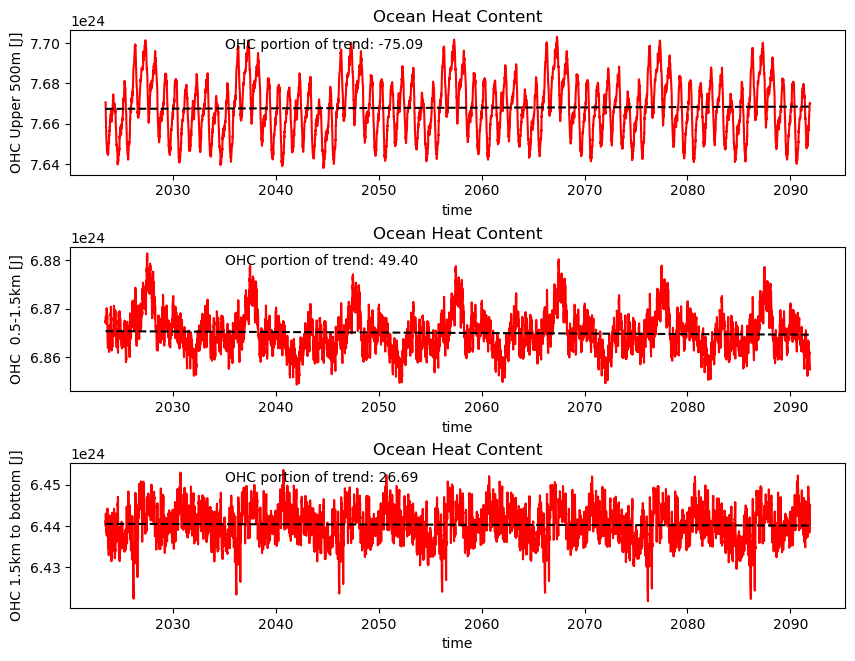

In [10]:
# Compute Basin Heat Content Time Series

Days_to_Eq = 2000
c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(3,1,figsize=(10,7.5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred_upper = ((ds_prediction['thetao'][Days_to_Eq:].sel(lev = slice(0,500))*c_p*rho_0)*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
OHC_pred_upper = OHC_pred_upper.rename('OHC Upper 500m')
OHC_pred_upper = OHC_pred_upper.assign_attrs(units = 'J')

OHC_pred_upper.plot(ax = ax[0], label = 'pred', c = 'r')
# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_upper[:].size), OHC_pred_upper[:], 1)
ax[0].plot(OHC_pred_upper[:].time.data, np.arange(OHC_pred_upper[:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'k', ls = '--')
upper_trend = coeffs_OHC_pred_trend[0]*73
# ax[0].annotate(f'OHC trend: {upper_trend:.2f} j/year',xy = (.25,.75), xycoords='figure fraction',
#             horizontalalignment='left', verticalalignment='top')

OHC_pred_mid = ((ds_prediction['thetao'][Days_to_Eq:].sel(lev = slice(500,1500))*c_p*rho_0)*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
OHC_pred_mid = OHC_pred_mid.rename('OHC  0.5-1.5km')
OHC_pred_mid = OHC_pred_mid.assign_attrs(units = 'J')

OHC_pred_mid.plot(ax = ax[1], label = 'pred', c = 'r')
# ax[0].legend()
ax[1].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_mid[:].size), OHC_pred_mid[:], 1)
ax[1].plot(OHC_pred_mid[:].time.data, np.arange(OHC_pred_mid[:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'k', ls = '--')
mid_trend = coeffs_OHC_pred_trend[0]*73


OHC_pred_deep = ((ds_prediction['thetao'][Days_to_Eq:].sel(lev = slice(1500,None))*c_p*rho_0)*ds_prediction['areacello']*ds_prediction['dz']).sum(['x','y','lev'])    
OHC_pred_deep = OHC_pred_deep.rename('OHC 1.5km to bottom')
OHC_pred_deep = OHC_pred_deep.assign_attrs(units = 'J')

OHC_pred_deep.plot(ax = ax[2], label = 'pred', c = 'r')
# ax[0].legend()
ax[2].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_deep[:].size), OHC_pred_deep[:], 1)
ax[2].plot(OHC_pred_deep[:].time.data, np.arange(OHC_pred_deep[:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'k', ls = '--')
deep_trend = coeffs_OHC_pred_trend[0]*73

total_trend = upper_trend + mid_trend + deep_trend
ax[0].annotate(f'OHC portion of trend: {upper_trend/total_trend:.2f}',xy = (.2,.95), xycoords='axes fraction',
            horizontalalignment='left', verticalalignment='top')

ax[1].annotate(f'OHC portion of trend: {mid_trend/total_trend:.2f}',xy = (.2,.95), xycoords='axes fraction',
            horizontalalignment='left', verticalalignment='top')

ax[2].annotate(f'OHC portion of trend: {deep_trend/total_trend:.2f}',xy = (.2,.95), xycoords='axes fraction',
            horizontalalignment='left', verticalalignment='top')

In [11]:
upper_trend

1.6144324343121238e+19

In [12]:
fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/OHC Different Depth Climate Change.png')

Text(0.5, 0.98, 'Depth Profiles')

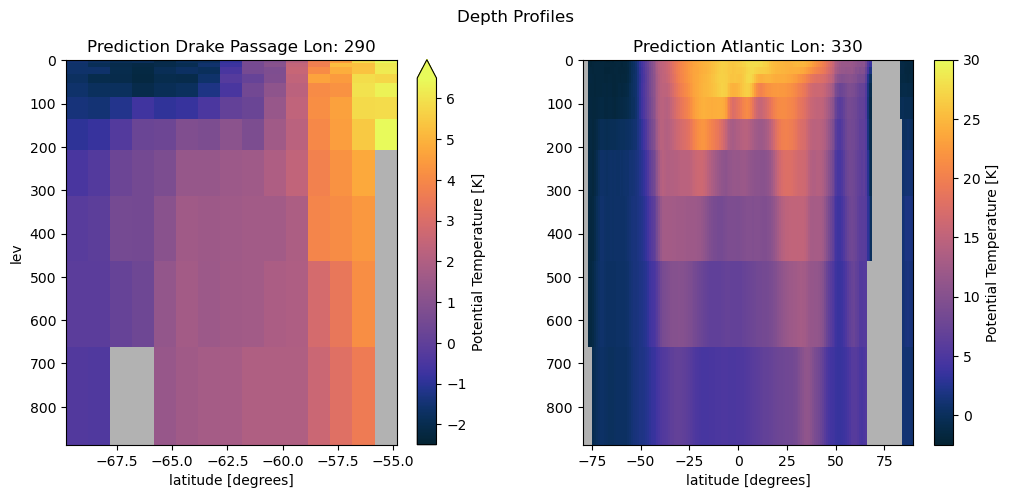

In [13]:
#Drake Passage Full Depth 

new_cmap = cm.cm.thermal 
# new_cmap = cm.cm.balance 

new_cmap.set_bad('grey',.6)

day_start = -100
window = 3
regions = {'Drake Passage': {'lon': 290, 'lat_bnds':slice(-70,-55)},
           'Atlantic': {'lon': 330, 'lat_bnds':slice(-80,90)}}
surface = True

fig, ax = plt.subplots(1,2,figsize=(12,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1], 'wspace': 0.25,'hspace':.5})
bounds = regions['Drake Passage']
var = 'thetao'
if surface:
    level_slice = slice(0,1000)
else:
    level_slice = slice(None)

depth_slice = ds_prediction[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
depth_slice = depth_slice.assign_attrs(long_name = 'Potential Temperature', units = 'K')

pred_plot = depth_slice.plot(y = 'lev',ax=ax[0],cmap = new_cmap, vmin = -2.5, vmax = 6.5)
ax[0].invert_yaxis()
ax[0].set_title('Prediction Drake Passage Lon: ' +  str(bounds['lon']))

bounds = regions['Atlantic']
depth_slice = ds_prediction[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
depth_slice = depth_slice.assign_attrs(long_name = 'Potential Temperature', units = 'K')

pred_plot = depth_slice.plot(y = 'lev',ax=ax[1],cmap = new_cmap, vmin = -2.5, vmax = 30)
ax[1].invert_yaxis()
ax[1].set_ylabel('')
ax[1].set_title('Prediction Atlantic Lon: ' +  str(bounds['lon']))

# fig.subplots_adjust(right=0.825)
# cbar_ax = fig.add_axes([0.85, 0.15, 0.015, 0.7])
# cbar = fig.colorbar(pred_plot, cax=cbar_ax)
# cbar.set_label(var,rotation = 90)
fig.suptitle(r"Depth Profiles" )

Text(0.5, 0.98, 'Depth Profiles')

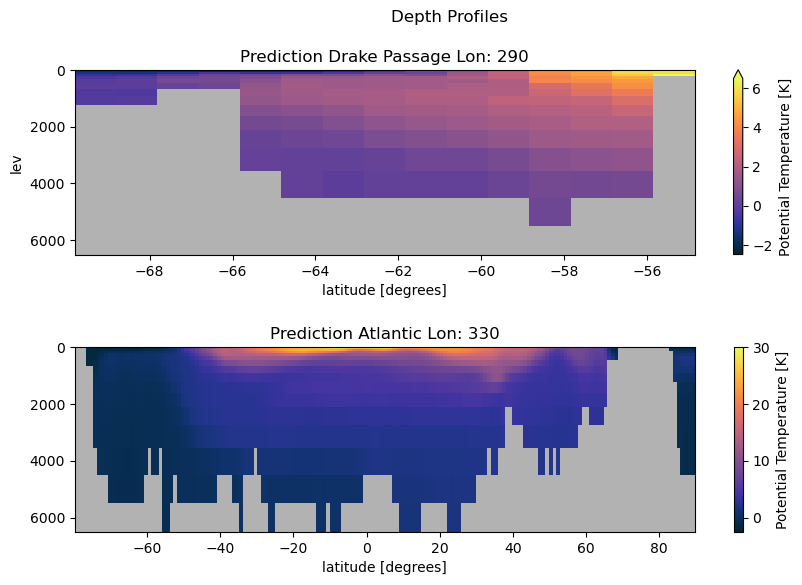

In [14]:
#Drake Passage Full Depth 

new_cmap = cm.cm.thermal 
# new_cmap = cm.cm.balance 

new_cmap.set_bad('grey',.6)

day_start = -100
window = 3
regions = {'Drake Passage': {'lon': 290, 'lat_bnds':slice(-70,-55)},
           'Atlantic': {'lon': 330, 'lat_bnds':slice(-80,90)},
           'Indian': {'lon': 95, 'lat_bnds':slice(-40,20)}}

surface = False

fig, ax = plt.subplots(2,1,figsize=(10,6),gridspec_kw={'width_ratios': [1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
bounds = regions['Drake Passage']
var = 'thetao'
if surface:
    level_slice = slice(0,1000)
else:
    level_slice = slice(None)

depth_slice = ds_prediction[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
depth_slice = depth_slice.assign_attrs(long_name = 'Potential Temperature', units = 'K')

pred_plot = depth_slice.plot(y = 'lev',ax=ax[0],cmap = new_cmap, vmin = -2.5, vmax = 6.5)
ax[0].invert_yaxis()
ax[0].set_title('Prediction Drake Passage Lon: ' +  str(bounds['lon']))

bounds = regions['Atlantic']
depth_slice = ds_prediction[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
depth_slice = depth_slice.assign_attrs(long_name = 'Potential Temperature', units = 'K')

pred_plot = depth_slice.plot(y = 'lev',ax=ax[1],cmap = new_cmap, vmin = -2.5, vmax = 30)
ax[1].invert_yaxis()
ax[1].set_ylabel('')
ax[1].set_title('Prediction Atlantic Lon: ' +  str(bounds['lon']))

# fig.subplots_adjust(right=0.825)
# cbar_ax = fig.add_axes([0.85, 0.15, 0.015, 0.7])
# cbar = fig.colorbar(pred_plot, cax=cbar_ax)
# cbar.set_label(var,rotation = 90)
fig.suptitle(r"Depth Profiles" )

/global/homes/a/asubel/.conda/envs/NERSC_Kernel/lib/python3.12/site-packages/regionmask/core/mask.py:179: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


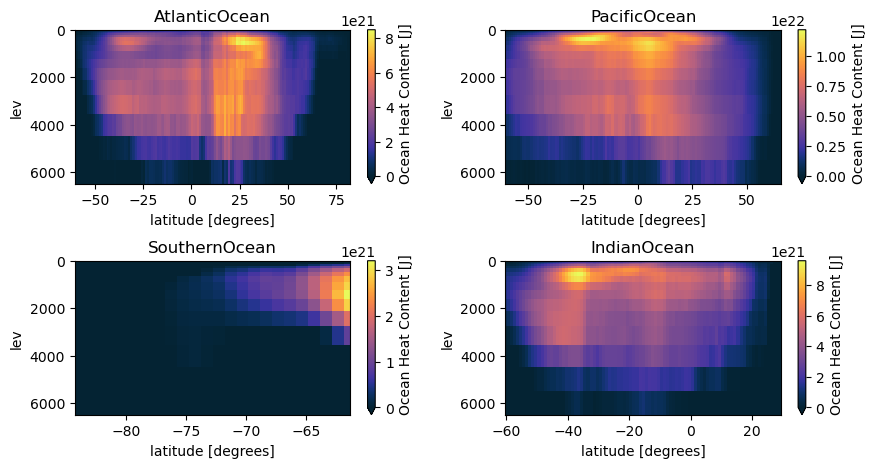

In [15]:
# Compute Basin Heat Content Time Series
new_cmap = cm.cm.thermal 
# new_cmap = cm.cm.balance 

new_cmap.set_bad('grey',.6)

basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

mask = merged_mask(basins,ds_prediction.drop_vars(['lat','lon']))

atlantic_mask = xr.where(np.logical_or(mask == 0,mask == 1),1.0,np.nan)
pacific_mask = xr.where(np.logical_or(mask == 2,mask == 3),1.0,np.nan)
southern_ocean_mask = xr.where(mask == 7,1.0,np.nan)
indian_ocean_mask = xr.where(mask == 5,1.0,np.nan)

masks = atlantic_mask.to_dataset(name='Atlantic')
masks['Pacific']  = pacific_mask
masks['Southern'] = southern_ocean_mask
masks['Indian'] = indian_ocean_mask

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
ax_flat = ax.flatten()

for i, var in enumerate(list(masks.keys())):
    OHC_pred = ((ds_prediction['thetao'].isel(time = slice(-730,None))*c_p*rho_0*masks[var])*ds_prediction['areacello']*ds_prediction['dz']).sum(['x']).mean('time')    
    OHC_pred = OHC_pred.rename('Ocean Heat Content')
    OHC_pred = OHC_pred.assign_attrs(units = 'J')
    min_lat = OHC_pred.y[np.logical_not(np.isnan(masks[var].mean('x')))][0]
    max_lat = OHC_pred.y[np.logical_not(np.isnan(masks[var].mean('x')))][-1]
    OHC_pred.plot(ax = ax_flat[i],cmap = new_cmap,vmin=0)
    ax_flat[i].set_xlim([min_lat,max_lat])
    ax_flat[i].invert_yaxis()  
    ax_flat[i].set_title(var + 'Ocean')


# fig.savefig('./figures/OHC_Short.png',dpi=250)

In [16]:
def NinoIndexComputeClim(T,area,dt = 5, window = 150):
    T_clim = T.copy()
    T_clim = T_clim.sel(x = slice(118,260), y = slice(-5,5)).load()
    area = area.sel(x = slice(118,260), y = slice(-5,5))
    clim = T_clim.groupby('time.dayofyear').mean('time').compute()
    window = int(window/dt)
    print(window)
    for i, t in enumerate(T_clim.time.values):
        day = int(Timestamp(t).dayofyear)
        T_clim[i] = (T[i]-clim.sel(dayofyear=day)).data        

    T_clim = T_clim.rolling(time = window).mean()
    T_clim = (T_clim*area).sum(["x","y"])/area.sum(["x","y"])

    return T_clim[window:]

In [17]:
clim_pred = ds_prediction['thetao'].sel(lev = slice(0,500)).groupby('time.dayofyear').mean().compute()

In [18]:
nino_pred_compute_clim = NinoIndexComputeClim(ds_prediction['thetao'][:,0],ds_prediction['areacello'])
nino_pred_compute_clim = nino_pred_compute_clim.rename('Nino 3.4')
nino_pred_compute_clim = nino_pred_compute_clim.assign_attrs(units = 'K')

30


OMP: Info #277: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [19]:
day_max = int((np.argwhere(nino_pred_compute_clim.values == np.nanmax(nino_pred_compute_clim.values[-1000:])) + 30).squeeze())
day_min = int((np.argwhere(nino_pred_compute_clim.values == np.nanmin(nino_pred_compute_clim.values[-1000:])) + 30).squeeze())

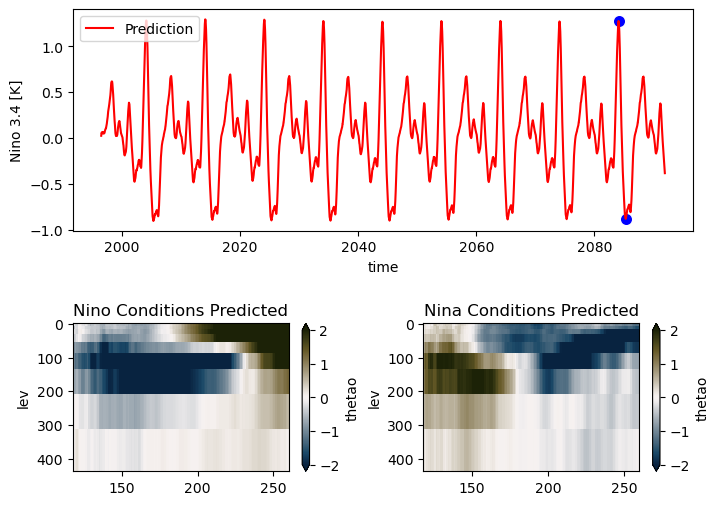

In [20]:

fig,axs = plt.subplot_mosaic([['time series','time series'],['nino_pred','nina_pred']],figsize = (8,6),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.6,.4], 'wspace': 0.3,'hspace':.5})
nino_pred_compute_clim.plot(label = 'Prediction', c = 'r',ax = axs['time series'])
nino_pred_compute_clim.isel(time = slice(day_max-30,day_max-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'b',ax = axs['time series'])
nino_pred_compute_clim.isel(time = slice(day_min-30,day_min-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'b',ax = axs['time series'])
axs['time series'].set_title('')
axs['time series'].legend()
# axs['time series'].set_title('Nino 3.4 Index')

day_start = day_max
window = 3
times = ds_prediction['time'][day_start:day_start+window].data

days_of_year = [Timestamp(i).dayofyear for i in times]
pred_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times

tropics_profile_pred = (ds_prediction['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])


tropics_profile_pred.plot.pcolormesh(ax = axs['nino_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nino_pred'].set_title('Nino Conditions Predicted')
axs['nino_pred'].set_xlabel('')
axs['nino_pred'].invert_yaxis()


axs['time series'].legend(loc = 'upper left')

day_start = day_min
window = 3
times = ds_prediction['time'][day_start:day_start+window].data

days_of_year = [Timestamp(i).dayofyear for i in times]
pred_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times

tropics_profile_pred = (ds_prediction['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])


tropics_profile_pred.plot.pcolormesh(ax = axs['nina_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nina_pred'].set_title('Nina Conditions Predicted')
axs['nina_pred'].set_xlabel('')
axs['nina_pred'].invert_yaxis()



In [21]:
fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Nino Long Run.png')